# TP M2-1 — Du signal brut à la fréquence cardiaque (PPG)

**Module 2 — vendredi 9 octobre 2026 — 10:00-12:30** (pause 10:45-11:00)
MBA Santé, IA & IoT — Epitech — Nicolas LAURIO
Énoncé complet : `TP_M2_1_Signal_PPG.md`

> Données : PhysioNet *BIDMC PPG and Respiration Dataset* v1.0.0 (licence ODC-BY 1.0 : on peut les utiliser en citant la source, voir la référence en fin de notebook). Le notebook les télécharge. Si le téléchargement échoue, il passe sur un signal **synthétique** (fabriqué par programme, il ne vient d'aucune personne). Usage **pédagogique** uniquement : ces calculs ne sont pas validés en médecine et ne servent à aucun diagnostic.

**Mode d'emploi**
- Vous n'écrivez pas de code. Exécutez les cellules **dans l'ordre** (Maj + Entrée). Le notebook marche de bout en bout sans rien changer.
- ▶ **Exécutez** : la cellule suivante se lance telle quelle.
- ✏️ **À vous** : la cellule suivante contient un réglage à changer. Dans Colab, c'est un **curseur** ; en local, changez seulement le nombre.
- Après un changement, relancez la cellule **et les suivantes** (Colab : menu *Exécution → Exécuter les cellules suivantes* ; Jupyter : *Run → Run Selected Cell and All Below*).
- Les **questions** sont en gras. Répondez dans la cellule « Vos réponses » juste en dessous (double-clic pour écrire, Maj + Entrée pour valider).

### Rappel en 5 lignes
1. **PPG** (photopléthysmographie) : la mesure du pouls par la lumière. Une petite lampe (LED) éclaire la peau, un capteur de lumière mesure ce qui revient. À chaque battement, il y a un peu plus de sang sous la peau : on obtient **une vague par battement**.
2. **Échantillonnage** : le capteur prend une mesure à intervalle régulier. Ici, **125 mesures par seconde** (fs = 125 Hz ; « Hz » veut dire « fois par seconde »), soit une mesure toutes les 8 ms. Pour connaître le temps, on divise le numéro de la mesure par 125 : la mesure n° 250 tombe à 250 ÷ 125 = 2 s.
3. **Passer des Hz aux bpm** (battements par minute) : on multiplie par 60. Un battement par seconde (1 Hz) = 60 bpm. Donc 40 à 180 bpm correspondent à 0,67 à 3 Hz.
4. Le signal brut contient aussi autre chose que le pouls : une **dérive lente** (respiration, posture : moins de 0,5 fois par seconde), un **bruit rapide** (plus de 5 fois par seconde) et des **artefacts de mouvement**, qui vont souvent à la même vitesse que le pouls.
5. **Filtrer**, c'est garder seulement les variations à la vitesse du pouls, pour mieux repérer les battements. Ce que le filtre ne peut pas enlever, un **indice de qualité** (une note de confiance) doit le signaler.

## Étape 0 — Votre numéro d'équipe

Chaque équipe analyse un patient différent : équipe 1 → `bidmc_01`, équipe 2 → `bidmc_02`… On comparera les résultats en plénière.

✏️ **À vous : changez seulement le numéro `EQUIPE`, puis exécutez la cellule.** Laissez `FORCER_SYNTHETIQUE = False` (sauf consigne de l'intervenant ou si le téléchargement échoue).

In [1]:
#@title À vous : numéro d'équipe
EQUIPE = "2"  #@param {type:"string"}
# Tapez seulement votre numéro d'équipe : 3, ou 03, les deux marchent.
FORCER_SYNTHETIQUE = False  #@param {type:"boolean"}
# FORCER_SYNTHETIQUE = True : utiliser le PPG synthétique même si le réseau fonctionne (test du repli)

▶ **Pas besoin de lire ce code : exécutez la cellule suivante sans la modifier.**

Elle prépare les outils (téléchargement, calculs, données de secours). Elle affiche seulement « Boîte à outils prête » et le numéro de votre enregistrement.

In [2]:
# ===== Boîte à outils : exécutez cette cellule sans la modifier =====
import json
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal

plt.rcParams["figure.figsize"] = (12, 3.5)
plt.rcParams["axes.grid"] = True

FS = 125            # fréquence d'échantillonnage de BIDMC : 125 mesures par seconde
FENETRE_S = 8.0     # une FC est calculée sur une fenêtre glissante de 8 s
URL_BIDMC = "https://physionet.org/files/bidmc/1.0.0/bidmc_csv/"
# --- Vérification du numéro d'équipe et du choix « données synthétiques » (tolère 3, "3", "03", True, "oui"...) ---
try:
    EQUIPE
except NameError:
    raise NameError("Exécutez d'abord la cellule « À vous : numéro d'équipe » (juste au-dessus).") from None
try:
    EQUIPE = int(str(EQUIPE).strip())
except ValueError:
    raise ValueError(f"EQUIPE doit être un numéro, par exemple 3 (vous avez écrit : {EQUIPE!r})") from None
if not 1 <= EQUIPE <= 99:
    raise ValueError(f"EQUIPE doit être un numéro entre 1 et 99 (vous avez écrit : {EQUIPE})")
try:
    FORCER_SYNTHETIQUE
except NameError:
    FORCER_SYNTHETIQUE = False
if isinstance(FORCER_SYNTHETIQUE, str):
    FORCER_SYNTHETIQUE = FORCER_SYNTHETIQUE.strip().lower() in ("true", "vrai", "oui", "1", "yes")
FORCER_SYNTHETIQUE = bool(FORCER_SYNTHETIQUE)

RECORD = f"{(EQUIPE - 1) % 53 + 1:02d}"   # équipe 1 -> "01", équipe 2 -> "02"... (53 enregistrements)


def trouver_ou_telecharger(nom):
    """Cherche le fichier à côté du notebook ou dans data/, sinon le télécharge depuis PhysioNet."""
    for dossier in (Path("."), Path("data")):
        if (dossier / nom).exists():
            return dossier / nom
    Path("data").mkdir(exist_ok=True)
    duree = "environ 3 Mo, de 30 s à 2 min" if "Signals" in nom else "quelques secondes"
    print(f"Téléchargement de {nom} depuis PhysioNet ({duree})...", flush=True)
    debut = time.time()
    with urllib.request.urlopen(URL_BIDMC + nom, timeout=60) as reponse:
        contenu = reponse.read()
    (Path("data") / nom).write_bytes(contenu)   # écrit seulement si le téléchargement est complet
    print(f"  terminé : {len(contenu) / 1e6:.1f} Mo en {time.time() - debut:.0f} s")
    return Path("data") / nom


def generer_ppg_synthetique(graine=1, duree_s=480, fs=FS):
    """PPG synthétique réaliste au format BIDMC (repli si pas de réseau). La FC « vraie » est connue."""
    rng = np.random.default_rng(graine)
    fc_moy = 62 + (graine * 11) % 40                     # chaque équipe a une FC moyenne différente
    t = np.arange(0, duree_s, 1 / fs)
    ppg = np.zeros_like(t)
    t_batt, fc_batt = [], []
    tb = 0.3
    while tb < duree_s:
        fc_i = fc_moy + 6 * np.sin(2 * np.pi * tb / 150) + 2 * np.sin(2 * np.pi * tb / 4) + rng.normal(0, 1)
        ibi = 60 / fc_i                                   # intervalle entre battements (s)
        i0, i1 = int(tb * fs), min(len(t), int((tb + 1.5) * fs))
        tt = t[i0:i1] - tb
        k = ibi / 0.8                                     # la forme d'onde s'adapte à la FC
        ppg[i0:i1] += (1 + rng.normal(0, 0.05)) * (
            np.exp(-((tt - 0.18 * k) ** 2) / (2 * (0.07 * k) ** 2))            # onde systolique
            + 0.45 * np.exp(-((tt - 0.42 * k) ** 2) / (2 * (0.10 * k) ** 2)))  # onde diastolique
        t_batt.append(tb)
        fc_batt.append(fc_i)
        tb += ibi
    ppg *= 1 + 0.10 * np.sin(2 * np.pi * 0.25 * t)         # respiration (15 /min) : amplitude
    ppg += 0.25 * np.sin(2 * np.pi * 0.25 * t + 0.5)       # respiration : ligne de base
    ppg += 0.30 * np.sin(2 * np.pi * 0.03 * t)             # dérive lente (posture, température)
    ppg += rng.normal(0, 0.03, len(t))                     # bruit électronique
    ppg = (ppg - ppg.min()) / (ppg.max() - ppg.min())      # normalisé entre 0 et 1 comme BIDMC
    secondes = np.arange(0, duree_s + 1)
    hr = np.round(np.interp(secondes, t_batt, fc_batt))
    signals = pd.DataFrame({"Time [s]": np.round(t, 3), "PLETH": ppg})
    numerics = pd.DataFrame({"Time [s]": secondes, "HR": hr, "PULSE": hr})
    return signals, numerics


def charger_enregistrement(record, forcer_synthetique=False, repli=True):
    """Renvoie (signals, numerics, source). Bascule sur le PPG synthétique en cas d'échec."""
    if not forcer_synthetique:
        try:
            sig = pd.read_csv(trouver_ou_telecharger(f"bidmc_{record}_Signals.csv"))
            num = pd.read_csv(trouver_ou_telecharger(f"bidmc_{record}_Numerics.csv"))
            sig.columns = sig.columns.str.strip()   # les noms commencent par une espace : " PLETH"
            num.columns = num.columns.str.strip()   # idem : " HR"
            if "PLETH" not in sig.columns or "HR" not in num.columns or len(sig) < 60 * FS:
                raise ValueError("fichier incomplet ou colonnes inattendues")
            return sig, num, f"BIDMC enregistrement {record}"
        except Exception as erreur:
            if not repli:
                raise
            print(f"Données BIDMC indisponibles : {erreur!r}")
    print("=" * 72)
    print("ATTENTION : données SYNTHÉTIQUES (repli). Signalez-le dans votre synthèse.")
    print("=" * 72)
    sig, num = generer_ppg_synthetique(graine=int(record))
    return sig, num, f"PPG synthétique (repli, graine {record})"


def reference_fc(numerics, t):
    """FC de référence du moniteur (colonne HR, une valeur par seconde), sans les bords."""
    ref = numerics[["Time [s]", "HR"]].dropna()
    garde = (ref["Time [s]"] >= FENETRE_S / 2) & (ref["Time [s]"] <= t[-1] - FENETRE_S / 2)
    return ref.loc[garde, "Time [s]"].to_numpy(float), ref.loc[garde, "HR"].to_numpy(float)


def fc_par_fenetre(t_pics, instants, fenetre=FENETRE_S):
    """Pour chaque instant : FC (médiane des intervalles) et irrégularité (CV) sur une fenêtre centrée."""
    ibi = np.diff(t_pics)            # intervalles entre battements (s)
    t_ibi = t_pics[1:]
    fc = np.full(len(instants), np.nan)
    cv = np.full(len(instants), np.nan)
    for k, tc in enumerate(instants):
        dans = (t_ibi >= tc - fenetre / 2) & (t_ibi < tc + fenetre / 2)
        if dans.sum() >= 3:          # au moins 3 intervalles pour calculer quelque chose
            fc[k] = 60 / np.median(ibi[dans])
            cv[k] = np.std(ibi[dans]) / np.mean(ibi[dans])   # coefficient de variation
    return fc, cv


def mae(fc_estimee, fc_reference, masque=None):
    """Erreur absolue moyenne (bpm), calculée là où une FC est disponible (et dans le masque)."""
    ok = ~np.isnan(fc_estimee)
    if masque is not None:
        ok &= masque
    return float(np.mean(np.abs(fc_estimee[ok] - fc_reference[ok]))) if ok.any() else float("nan")


def ajouter_artefact(x, t, debut, duree, gain, graine=0):
    """Simule un mouvement : bruit dans la bande 1-3 Hz (comme une marche) + sauts de ligne de base."""
    rng = np.random.default_rng(graine)
    y = x.copy()
    zone = (t >= debut) & (t < debut + duree)
    bruit = signal.sosfilt(signal.butter(2, [1, 3], btype="bandpass", fs=FS, output="sos"),
                           rng.normal(0, 1, zone.sum()))
    bruit = gain * np.std(x) * bruit / np.std(bruit)
    sauts = np.cumsum(rng.normal(0, 0.02, zone.sum())) * np.std(x)
    y[zone] += bruit + sauts
    return y


print(f"Boîte à outils prête. Équipe {EQUIPE} -> enregistrement bidmc_{RECORD}.")

Boîte à outils prête. Équipe 2 -> enregistrement bidmc_02.


## Étape 1 — Charger l'enregistrement

Le notebook cherche les fichiers `bidmc_XX_Signals.csv` et `bidmc_XX_Numerics.csv` à côté du notebook (ou dans `data/`). Sinon, il les télécharge depuis PhysioNet. **Patientez** : cela prend de 30 s à 2 min. En cas d'échec, il passe sur des données synthétiques et l'affiche en gros.

- `Signals` : les signaux, 125 mesures par seconde. La colonne **`PLETH`** est le signal du capteur de pouls (le PPG).
- `Numerics` : les valeurs du moniteur, une par seconde. **`HR`** est la FC du moniteur : c'est notre **référence**, la valeur considérée comme juste.

▶ **Exécutez la cellule suivante.**

**Vous devez voir** : `Source : BIDMC enregistrement XX`, 60001 échantillons (mesures), une durée de 480 s.

In [3]:
signals, numerics, SOURCE = charger_enregistrement(RECORD, FORCER_SYNTHETIQUE)

ppg_brut = signals["PLETH"].to_numpy(dtype=float)
t = np.arange(len(ppg_brut)) / FS     # temps (s) = numéro d'échantillon / fréquence d'échantillonnage

print("Source :", SOURCE)
print("Colonnes Signals  :", list(signals.columns))
print("Colonnes Numerics :", list(numerics.columns))
print(f"{len(ppg_brut)} échantillons à {FS} Hz -> durée {t[-1]:.0f} s ({t[-1] / 60:.0f} min)")
print(f"FC de référence (HR) : moyenne {numerics['HR'].mean():.0f} bpm, "
      f"de {numerics['HR'].min():.0f} à {numerics['HR'].max():.0f} bpm")
numerics.head()

Source : BIDMC enregistrement 02
Colonnes Signals  : ['Time [s]', 'II', 'PLETH', 'RESP', 'V', 'AVR']
Colonnes Numerics : ['Time [s]', 'HR', 'PULSE', 'RESP', 'SpO2']
60001 échantillons à 125 Hz -> durée 480 s (8 min)
FC de référence (HR) : moyenne 91 bpm, de 87 à 95 bpm


,Time [s],HR,PULSE,RESP,SpO2
0,0,93,92,16,100
1,1,93,93,16,100
2,2,93,93,16,100
3,3,94,94,16,100
4,4,94,94,16,100


**Question 1.** Combien de mesures (échantillons) contient l'enregistrement ? Vérifiez avec un calcul : 480 secondes × 125 mesures par seconde = ? Combien de millisecondes séparent deux mesures (1 000 ÷ 125) ?

**Réponse 1.** Le fichier contient **60 001 échantillons**. Le calcul 480 × 125 = **60 000** compte les intervalles sur 480 secondes ; avec les deux extrémités, de t = 0 à t = 480 s incluses, on obtient 60 001 points. Deux mesures sont séparées de 1 000 / 125 = **8 ms**.

## Étape 2 — Regarder 10 secondes de signal brut

Le signal « brut », c'est le signal tel qu'il sort du capteur, pas encore traité.

✏️ **À vous** : `DEBUT_ZOOM` choisit les 10 secondes affichées (par défaut de 60 à 70 s). Exécutez la cellule, puis comptez les battements **avant** de lire la FC de référence affichée dessous.

**Vous devez voir** : une « vague » par battement, souvent suivie d'une petite bosse (l'onde diastolique, un rebond normal du pouls), le tout posé sur une ondulation plus lente.

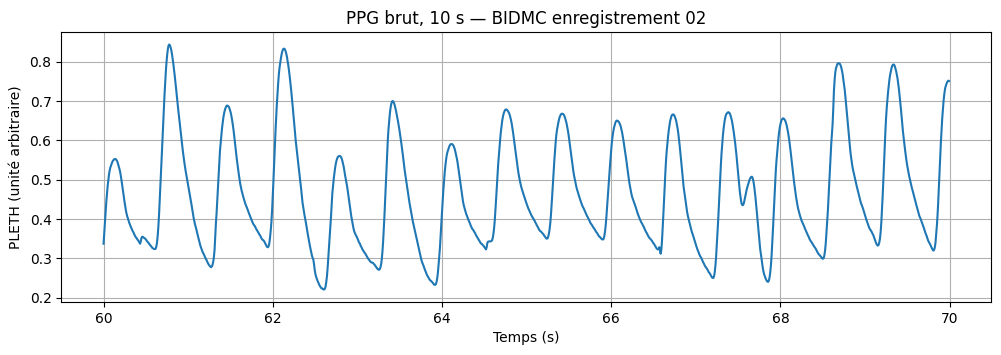

(À regarder APRÈS avoir compté) FC de référence sur ces 10 s : 90 bpm


In [4]:
#@title À vous : début de la fenêtre de 10 s
DEBUT_ZOOM = 60  #@param {type:"slider", min:0, max:460, step:10}

zoom = (t >= DEBUT_ZOOM) & (t < DEBUT_ZOOM + 10)
plt.plot(t[zoom], ppg_brut[zoom])
plt.title(f"PPG brut, 10 s — {SOURCE}")
plt.xlabel("Temps (s)")
plt.ylabel("PLETH (unité arbitraire)")
plt.show()

hr_zoom = numerics.loc[(numerics["Time [s]"] >= DEBUT_ZOOM) & (numerics["Time [s]"] < DEBUT_ZOOM + 10), "HR"]
print(f"(À regarder APRÈS avoir compté) FC de référence sur ces 10 s : {hr_zoom.mean():.0f} bpm")

**Question 2.** Comptez les battements sur ces 10 s, puis multipliez par 6 pour avoir des bpm (10 s = un sixième de minute ; exemple : 12 battements → 72 bpm). Êtes-vous proches de la FC de référence affichée sous le graphique (regardez-la **après** avoir compté) ?

**Réponse 2.** Sur la courbe brute de 60 à 70 s, on distingue **15 sommets complets** et un battement tronqué au bord droit : 15 × 6 = **90 bpm**, proche de la référence de **90,2 bpm**. Le comptage sur seulement 10 s est sensible aux bords : compter aussi le dernier battement donnerait 96 bpm. Le détecteur sur le signal filtré place effectivement son dernier pic à 69,992 s et en compte 16 dans cette fenêtre ; ce n'est pas une contradiction avec le comptage visuel des sommets complets du signal brut.

## Étape 3 — Nettoyer le signal avec un filtre

Le **filtre passe-bande** marche comme un tamis : il garde seulement les variations dont la vitesse est comprise entre `F_BAS` et `F_HAUT` (en fois par seconde, Hz). Il enlève l'ondulation lente et le bruit rapide. `ORDRE` règle la netteté de la coupure.

Le troisième graphique s'appelle le **spectre**. Il montre, de gauche (lent) à droite (rapide), à quelles vitesses le signal brut varie le plus. Zone verte = ce que le filtre garde. Trait rouge = la FC de référence.

✏️ **À vous** :
1. Exécutez d'abord avec le réglage par défaut (**0,5-5 Hz**).
2. Mettez `F_HAUT` à 1 (**0,5-1 Hz**, trop étroit), relancez cette cellule et les suivantes, et comparez.
3. **Revenez à 0,5-5 Hz** : ce réglage sert pour toute la suite.

**Vous devez voir** (0,5-5 Hz) : un signal centré sur 0, sans ondulation lente, avec des pics nets ; le trait rouge dans la zone verte.

*Détail technique (facultatif) : `fs=FS` dit à SciPy que 0,5 et 5 sont des hertz ; `sosfiltfilt` filtre dans un sens puis dans l'autre, donc les pics restent à leur place.*

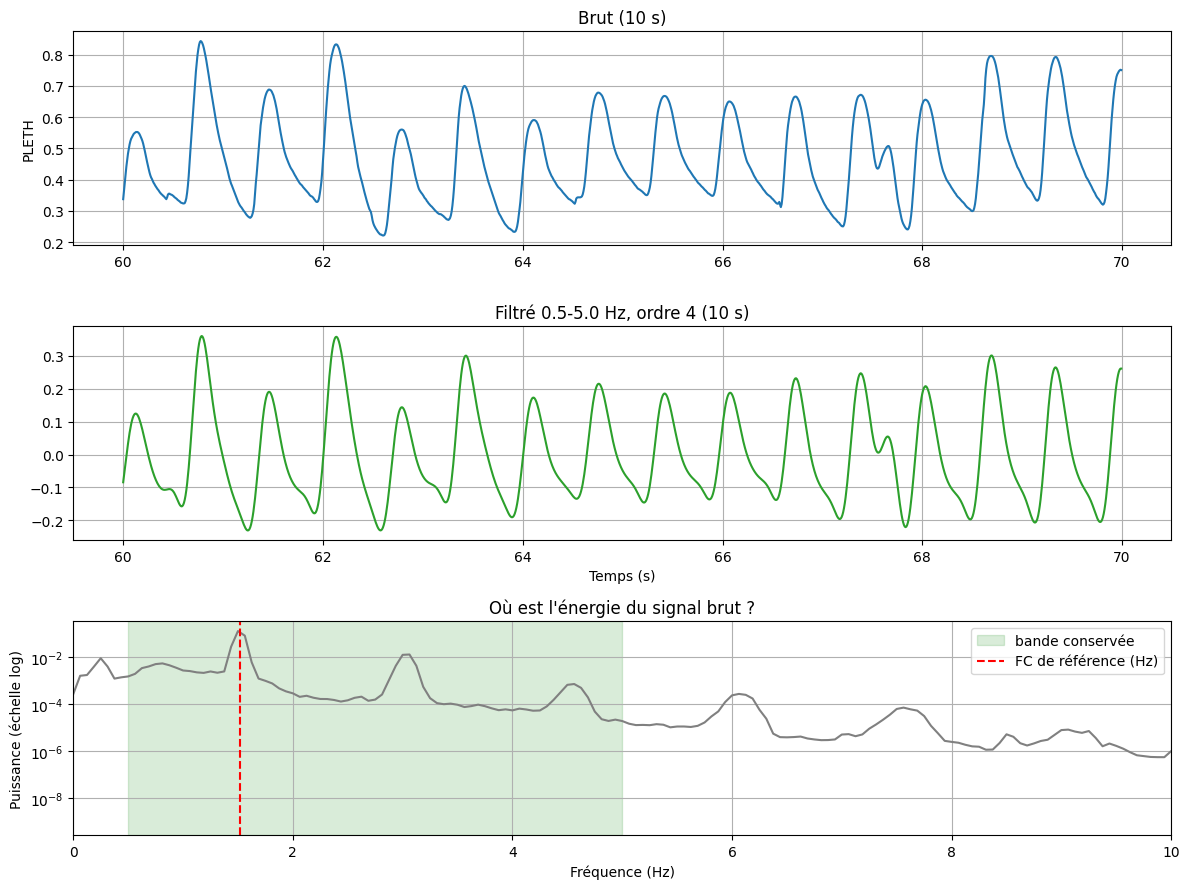

In [5]:
#@title À vous : réglage du filtre { run: "auto" }
F_BAS = 0.5  #@param {type:"slider", min:0.1, max:3, step:0.1}
F_HAUT = 5.0  #@param {type:"slider", min:1, max:20, step:0.5}
ORDRE = 4  #@param {type:"slider", min:1, max:8, step:1}

if F_BAS >= F_HAUT:
    raise ValueError("F_BAS doit être strictement inférieure à F_HAUT : corrigez le réglage.")

sos = signal.butter(ORDRE, [F_BAS, F_HAUT], btype="bandpass", fs=FS, output="sos")  # le filtre
ppg_filtre = signal.sosfiltfilt(sos, ppg_brut)                                      # aller-retour

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
axes[0].plot(t[zoom], ppg_brut[zoom])
axes[0].set(title="Brut (10 s)", ylabel="PLETH")
axes[1].plot(t[zoom], ppg_filtre[zoom], color="tab:green")
axes[1].set(title=f"Filtré {F_BAS}-{F_HAUT} Hz, ordre {ORDRE} (10 s)", xlabel="Temps (s)")
f, dsp = signal.welch(ppg_brut - ppg_brut.mean(), fs=FS, nperseg=16 * FS)
axes[2].semilogy(f, dsp, color="gray")
axes[2].axvspan(F_BAS, F_HAUT, color="green", alpha=0.15, label="bande conservée")
axes[2].axvline(numerics["HR"].mean() / 60, color="red", ls="--", label="FC de référence (Hz)")
axes[2].set(xlim=(0, 10), title="Où est l'énergie du signal brut ?", xlabel="Fréquence (Hz)",
            ylabel="Puissance (échelle log)")
axes[2].legend()
plt.tight_layout()
plt.show()

**Question 3.** Convertissez 0,5 Hz et 5 Hz en bpm (on multiplie par 60 ; exemple : 2 Hz × 60 = 120 bpm). Pourquoi garder cette bande, en une phrase ? Avec 0,5-1 Hz, que devient la courbe, et pourquoi ? (Aide : sur le spectre, le trait rouge est-il encore dans la zone verte ?)

*Repère horaire : vers 10:45, vous devriez avoir terminé cette étape (pause 10:45-11:00).*

**Réponse 3.** 0,5 Hz correspond à **30 bpm** et 5 Hz à **300 bpm**. Cette bande conserve le rythme cardiaque et une partie de ses harmoniques, utiles à la forme des pics, tout en réduisant la dérive lente et le bruit rapide. Elle ne signifie pas que l'on accepte une FC de 300 bpm : la plausibilité est contrôlée séparément. Avec 0,5–1 Hz, la courbe est très atténuée et déformée : la fondamentale du patient, environ **1,52 Hz**, est hors de la bande. On conserve **0,5–5 Hz, ordre 4**.

## Étape 4 — Repérer les battements (les pics)

Le notebook cherche les sommets de la courbe filtrée, avec deux garde-fous :
- **`FC_MAX`** fixe le temps minimum entre deux pics. En mots : 60 secondes divisées par la FC la plus haute possible. Exemple : 60 ÷ 180 = 0,33 s, soit 0,33 × 125 ≈ 41 mesures.
- **`PROEMINENCE`** fixe la hauteur minimale d'un pic, pour ignorer la petite bosse qui suit chaque battement (et le bruit).

✏️ **À vous** :
1. Exécutez avec le réglage par défaut et notez le nombre de battements.
2. Testez `FC_MAX` = 60, notez.
3. Testez `FC_MAX` = 300 avec `PROEMINENCE` = 0, notez.
4. **Revenez à 180 et 0,5.**

**Vous devez voir** (réglage par défaut) : un triangle rouge sur chaque grand pic, aucun sur la petite bosse qui suit.

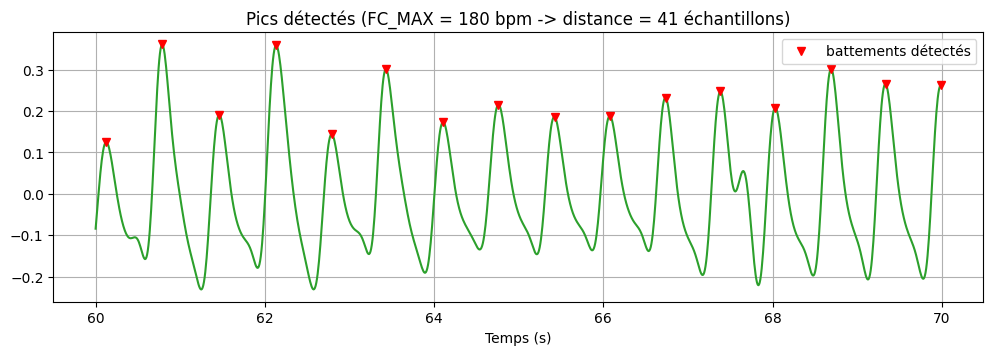

16 battements sur les 10 s affichées, 727 sur l'enregistrement complet


In [6]:
#@title À vous : réglage de la détection { run: "auto" }
FC_MAX = 180  #@param {type:"slider", min:40, max:300, step:10}
PROEMINENCE = 0.5  #@param {type:"slider", min:0, max:2, step:0.1}

distance_min = int(FS * 60 / FC_MAX)     # écart minimal entre deux pics, en échantillons
pics, _ = signal.find_peaks(ppg_filtre, distance=distance_min,
                            prominence=PROEMINENCE * np.std(ppg_filtre))
t_pics = t[pics]                         # instants des battements (s)

dans_zoom = (t_pics >= DEBUT_ZOOM) & (t_pics < DEBUT_ZOOM + 10)
plt.plot(t[zoom], ppg_filtre[zoom], color="tab:green")
plt.plot(t_pics[dans_zoom], ppg_filtre[pics][dans_zoom], "rv", label="battements détectés")
plt.title(f"Pics détectés (FC_MAX = {FC_MAX} bpm -> distance = {distance_min} échantillons)")
plt.xlabel("Temps (s)")
plt.legend()
plt.show()
print(f"{dans_zoom.sum()} battements sur les 10 s affichées, {len(pics)} sur l'enregistrement complet")

**Question 4.** Notez le nombre de battements détectés sur tout l'enregistrement avec `FC_MAX` = 60, puis avec `FC_MAX` = 300 et `PROEMINENCE` = 0. Dans chaque cas : trop peu ou trop de battements ? Pourquoi, en une phrase ? Quel réglage gardez-vous ?

**Réponse 4.** Avec `FC_MAX = 60` et une proéminence de 0,5, on détecte **325 pics** : trop peu, car l'écart imposé d'une seconde exclut des battements espacés d'environ 0,66 s. Avec `FC_MAX = 300` et `PROEMINENCE = 0`, on détecte **816 pics** : trop, car des bosses secondaires sont acceptées. On conserve **180 bpm et 0,5**, soit **727 pics** sur l'enregistrement.

## Étape 5 — Calculer la FC

- Le **temps entre deux battements** (IBI dans le code) se mesure en secondes, d'un pic au suivant.
- **FC instantanée** : on divise 60 par ce temps. Exemple : 0,8 s → 60 ÷ 0,8 = 75 bpm. Une valeur par battement.
- **FC moyenne** : on divise 60 par la moyenne de ces temps. Exemple : 0,66 s → 60 ÷ 0,66 ≈ 91 bpm.

▶ **Exécutez la cellule suivante.**

**Vous devez voir** : un nuage de points assez plat autour de la FC moyenne, avec parfois quelques points isolés très hauts ou très bas. Notez l'instant (en secondes) de ces points.

FC moyenne estimée : 90.9 bpm (référence HR moyenne : 91.1 bpm)
FC instantanée : min 47, médiane 91, max 100 bpm


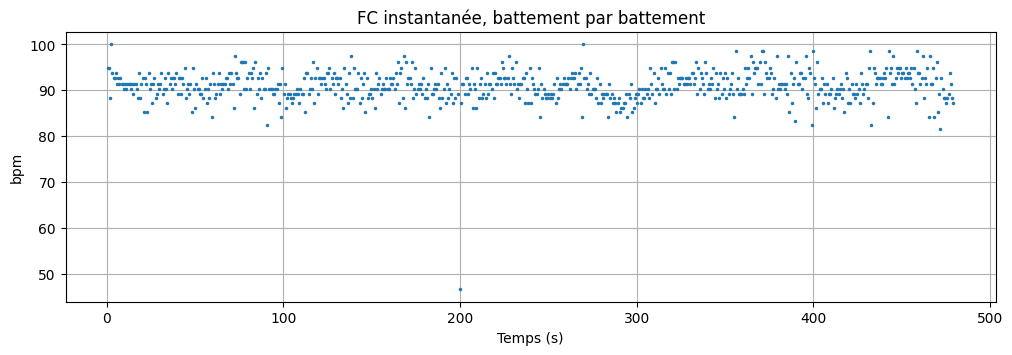

In [7]:
ibi = np.diff(t_pics)        # intervalles entre battements (s)
fc_inst = 60 / ibi           # FC instantanée (bpm), une valeur par battement
fc_moyenne = 60 / np.mean(ibi)

print(f"FC moyenne estimée : {fc_moyenne:.1f} bpm (référence HR moyenne : {numerics['HR'].mean():.1f} bpm)")
print(f"FC instantanée : min {fc_inst.min():.0f}, médiane {np.median(fc_inst):.0f}, max {fc_inst.max():.0f} bpm")

plt.plot(t_pics[1:], fc_inst, ".", ms=3)
plt.title("FC instantanée, battement par battement")
plt.xlabel("Temps (s)")
plt.ylabel("bpm")
plt.show()

**Question 5.** Votre FC moyenne est-elle proche de la référence (oui / non, écart en bpm) ? Voyez-vous des points très bas ou très hauts (moins de 40 ou plus de 180 bpm) ? Si oui, zoomez sur l'un d'eux (étape 2, curseur `DEBUT_ZOOM`) : que voyez-vous sur la courbe ?

**Réponse 5.** Oui : la FC moyenne estimée est **90,89 bpm**, contre **91,07 bpm** pour la référence, soit **0,18 bpm d'écart** (estimation légèrement inférieure). La FC instantanée varie d'environ **47 à 100 bpm** : aucun point n'est inférieur à 40 ou supérieur à 180 bpm. Le minimum proche de 200 s est néanmoins examiné dans le zoom de l'étape 8.

## Étape 6 — Comparer à la FC du moniteur

Le moniteur donne une FC par seconde. Le notebook calcule aussi une FC par seconde, sur les 8 secondes autour : c'est une **fenêtre glissante**, comme une loupe qu'on fait avancer. Il prend la **médiane** des temps entre battements (la valeur du milieu), pour qu'un battement raté compte peu.

L'**erreur moyenne** (MAE dans le code) dit de combien de bpm on se trompe, en moyenne. Chaque seconde, on prend l'écart entre notre FC et celle du moniteur, sans le signe, puis on fait la moyenne. Exemple : écarts de 1, 3 et 2 bpm → (1 + 3 + 2) ÷ 3 = 2 bpm. Le notebook la calcule aussi **sans filtre**, pour voir ce que le filtre apporte.

▶ **Exécutez la cellule suivante.**

**Vous devez voir** : deux courbes presque superposées et une erreur moyenne de 0,4 à 2 bpm environ (enregistrements BIDMC, réglage par défaut).

MAE avec filtre 0.5-5.0 Hz : 0.80 bpm
MAE sans filtre        : 0.78 bpm


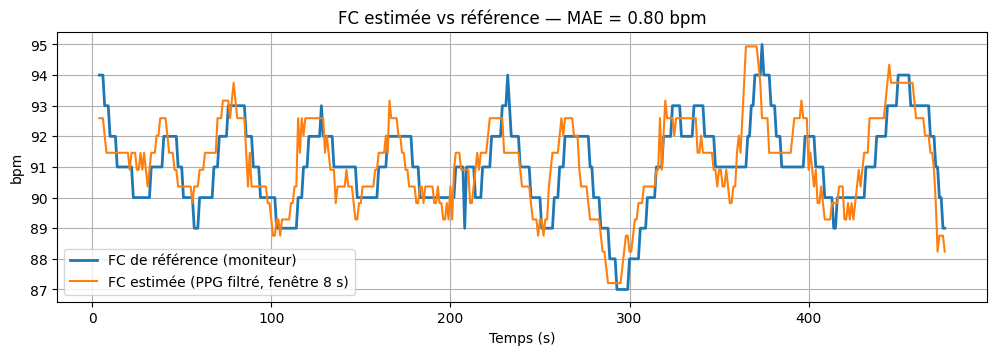

In [8]:
instants, fc_ref = reference_fc(numerics, t)            # une FC de référence par seconde
fc_est, cv_est = fc_par_fenetre(t_pics, instants)        # notre FC par seconde (fenêtre 8 s)
mae_filtre = mae(fc_est, fc_ref)


def estimer_fc(x, filtrer=True):
    """Chaîne complète avec VOS réglages : filtre -> pics -> FC par fenêtre de 8 s."""
    x = signal.sosfiltfilt(sos, x) if filtrer else x - np.mean(x)
    p, _ = signal.find_peaks(x, distance=distance_min, prominence=PROEMINENCE * np.std(x))
    return fc_par_fenetre(t[p], instants)


fc_sans_filtre, _ = estimer_fc(ppg_brut, filtrer=False)
mae_brut = mae(fc_sans_filtre, fc_ref)

print(f"MAE avec filtre {F_BAS}-{F_HAUT} Hz : {mae_filtre:.2f} bpm")
print(f"MAE sans filtre        : {mae_brut:.2f} bpm")

plt.plot(instants, fc_ref, label="FC de référence (moniteur)", lw=2)
plt.plot(instants, fc_est, label="FC estimée (PPG filtré, fenêtre 8 s)")
plt.title(f"FC estimée vs référence — MAE = {mae_filtre:.2f} bpm")
plt.xlabel("Temps (s)")
plt.ylabel("bpm")
plt.legend()
plt.show()

**Question 6.** Notez l'erreur moyenne (MAE) avec et sans filtre. Sur votre patient, le filtre aide-t-il (oui / non) ? Une erreur de cet ordre est-elle acceptable pour un appareil de suivi à domicile ? Pourquoi, en une phrase ?

**Réponse 6.** La MAE vaut **0,799 bpm avec filtre** et **0,775 bpm sans filtre**. Sur ce patient, le filtre **n'améliore pas** la MAE : elle augmente d'environ 0,023 bpm, une différence faible. Une erreur moyenne inférieure à 1 bpm est encourageante pour le suivi d'une tendance au repos, mais cet essai sur un seul enregistrement ne suffit pas à valider un appareil à domicile : les erreurs maximales, le mouvement, les rythmes atypiques et la disponibilité des mesures comptent aussi.

## Étape 7 — Simuler un mouvement du patient

Les patients de BIDMC sont allongés et immobiles. À domicile, on bouge. Le notebook ajoute donc un **artefact** : une perturbation qui ne vient pas du cœur. Il imite un bras qui bouge pendant la marche : des secousses de 1 à 3 fois par seconde (**1 à 3 Hz**), plus des sauts brusques du niveau du signal, de 200 à 240 s. `GAIN_ARTEFACT` règle la force du mouvement (0 = pas de mouvement).

✏️ **À vous** :
1. Exécutez avec le gain par défaut (3). Notez l'erreur sur tout l'enregistrement et l'erreur pendant l'artefact.
2. Mettez le gain à 1, relancez, notez les deux mêmes chiffres.
3. **Revenez à 3** : c'est le réglage de la suite et de votre ligne de résultats.

**Vous devez voir** : un signal désordonné dans la zone rouge, et une FC estimée qui s'écarte de la référence dans cette zone.

MAE sur tout l'enregistrement : 2.35 bpm (sans artefact : 0.80 bpm)
MAE pendant l'artefact        : 19.08 bpm (sans artefact, mêmes secondes : 0.78 bpm)
Pire écart pendant l'artefact : 44 bpm


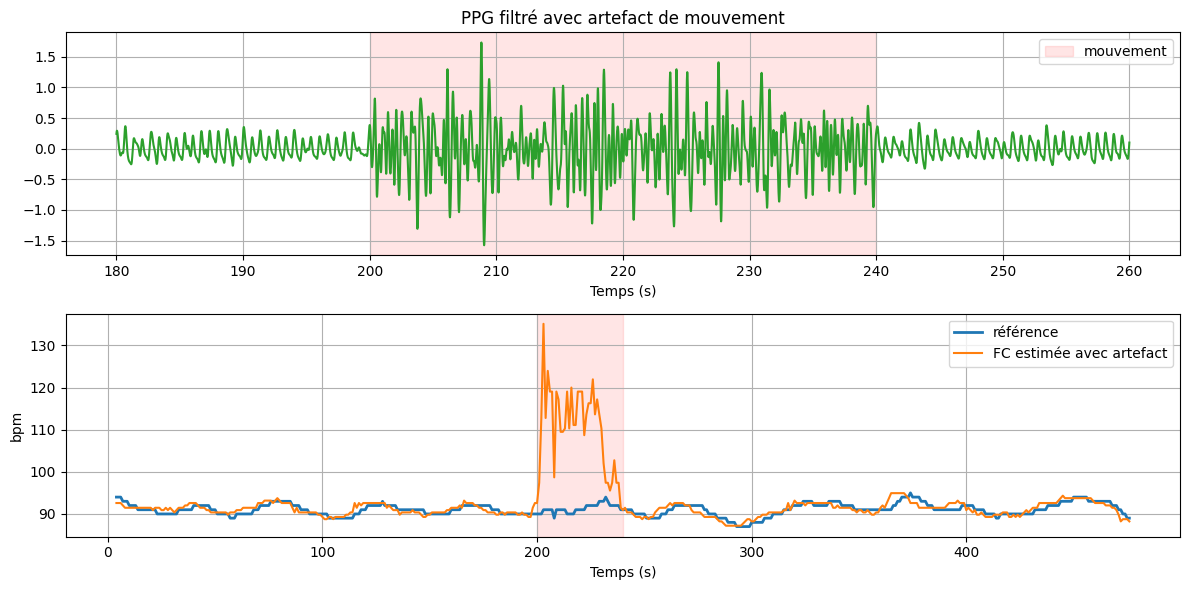

In [9]:
#@title À vous : artefact de mouvement { run: "auto" }
GAIN_ARTEFACT = 3.0  #@param {type:"slider", min:0, max:10, step:0.5}
DEBUT_ARTEFACT = 200  #@param {type:"slider", min:20, max:400, step:10}
DUREE_ARTEFACT = 40  #@param {type:"slider", min:10, max:60, step:10}

ppg_art = ajouter_artefact(ppg_brut, t, DEBUT_ARTEFACT, DUREE_ARTEFACT, GAIN_ARTEFACT)
fc_art, cv_art = estimer_fc(ppg_art)
zone_art = (instants >= DEBUT_ARTEFACT) & (instants < DEBUT_ARTEFACT + DUREE_ARTEFACT)

mae_art = mae(fc_art, fc_ref)
mae_art_zone = mae(fc_art, fc_ref, zone_art)
print(f"MAE sur tout l'enregistrement : {mae_art:.2f} bpm (sans artefact : {mae_filtre:.2f} bpm)")
print(f"MAE pendant l'artefact        : {mae_art_zone:.2f} bpm "
      f"(sans artefact, mêmes secondes : {mae(fc_est, fc_ref, zone_art):.2f} bpm)")
print(f"Pire écart pendant l'artefact : {np.nanmax(np.abs(fc_art - fc_ref)[zone_art]):.0f} bpm")

vue = (t >= DEBUT_ARTEFACT - 20) & (t < DEBUT_ARTEFACT + DUREE_ARTEFACT + 20)
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t[vue], signal.sosfiltfilt(sos, ppg_art)[vue], color="tab:green")
axes[0].axvspan(DEBUT_ARTEFACT, DEBUT_ARTEFACT + DUREE_ARTEFACT, color="red", alpha=0.1, label="mouvement")
axes[0].set(title="PPG filtré avec artefact de mouvement", xlabel="Temps (s)")
axes[0].legend()
axes[1].plot(instants, fc_ref, label="référence", lw=2)
axes[1].plot(instants, fc_art, label="FC estimée avec artefact")
axes[1].axvspan(DEBUT_ARTEFACT, DEBUT_ARTEFACT + DUREE_ARTEFACT, color="red", alpha=0.1)
axes[1].set(xlabel="Temps (s)", ylabel="bpm")
axes[1].legend()
plt.tight_layout()
plt.show()

**Question 7.** Notez l'erreur moyenne (MAE) pendant l'artefact pour un gain de 3, puis de 1. Pourquoi le filtre 0,5-5 Hz n'enlève-t-il pas ce mouvement ? (Aide : le mouvement va de 1 à 3 Hz.) Pourquoi l'erreur sur tout l'enregistrement augmente-t-elle beaucoup moins ?

**Réponse 7.** Pour le gain **3**, la MAE pendant l'artefact est **19,08 bpm** (MAE globale **2,35 bpm**, pire écart **44,14 bpm**). Pour le gain **1**, elle est de **7,90 bpm** (MAE globale **1,40 bpm**, pire écart **28,97 bpm**). Le mouvement entre 1 et 3 Hz se situe dans la bande 0,5–5 Hz : le filtre le conserve donc en partie. La MAE globale augmente beaucoup moins, car la perturbation ne dure que 40 s sur 480 s, soit environ **8,3 %** de l'enregistrement. Le gain final est remis à **3**.

## Étape 8 — Une note de confiance et la règle produit

Au repos, les battements sont **réguliers**. Un mouvement crée des « faux battements » espacés au hasard. Pour chaque fenêtre de 8 s, le notebook mesure donc la régularité avec le **CV** (coefficient de variation) : la dispersion des temps entre battements (leur écart-type) divisée par leur moyenne. Exemple : 0,03 ÷ 0,66 ≈ 0,05. Petit CV = battements réguliers.

Une fenêtre est de **qualité suffisante** si le CV est plus petit que `SEUIL_CV` **et** si la FC est entre 40 et 180 bpm.

**Règle produit** : *si la qualité est insuffisante, l'appareil n'envoie pas de FC* ; il envoie « qualité insuffisante ». On suit deux chiffres : la **justesse** des FC envoyées (leur erreur moyenne) et le **taux de transmission** (la part du temps où une FC est envoyée).

✏️ **À vous** :
1. Exécutez avec `SEUIL_CV` = 0,15 et notez les deux chiffres.
2. Testez 0,30 et notez les deux mêmes chiffres.
3. Regardez la ligne **sans artefact** : la FC est-elle envoyée 100 % du temps ?
4. Revenez au seuil que vous retenez.

**Vous devez voir** : la zone du mouvement rejetée (bandes rouges), une erreur des FC envoyées proche de celle sans mouvement, et un taux de transmission inférieur à 100 %.

sans artefact : FC transmise  98.3 % du temps | MAE des FC transmises  0.80 bpm | MAE sans règle  0.80 bpm
avec artefact : FC transmise  90.1 % du temps | MAE des FC transmises  0.80 bpm | MAE sans règle  2.35 bpm
Pendant l'artefact : FC transmise 0 % du temps


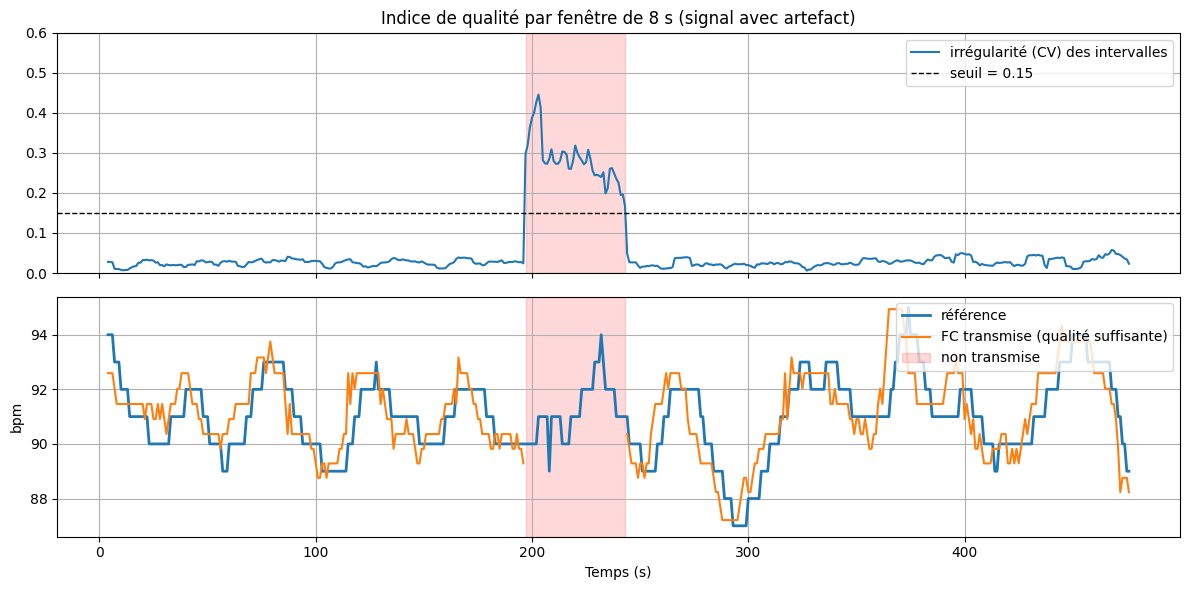

{"t_s": 170, "heart_rate": 93, "hr_quality": "ok"}
{"t_s": 220, "heart_rate": null, "hr_quality": "insuffisante"}
{"t_s": 270, "heart_rate": 92, "hr_quality": "ok"}


In [10]:
#@title À vous : seuil de qualité { run: "auto" }
SEUIL_CV = 0.15  #@param {type:"slider", min:0.02, max:0.5, step:0.01}


def qualite_suffisante(fc, cv):
    """Vrai si la fenêtre est régulière ET la FC plausible."""
    return (cv < SEUIL_CV) & (fc >= 40) & (fc <= 180)   # (les fenêtres vides donnent Faux)


ok_propre = qualite_suffisante(fc_est, cv_est)   # signal d'origine
ok_art = qualite_suffisante(fc_art, cv_art)      # signal avec artefact
fc_transmise = np.where(ok_art, fc_art, np.nan)  # règle produit : rien si qualité insuffisante

for nom, fc, ok in [("sans artefact", fc_est, ok_propre), ("avec artefact", fc_art, ok_art)]:
    print(f"{nom:>13} : FC transmise {100 * ok.mean():5.1f} % du temps | "
          f"MAE des FC transmises {mae(fc, fc_ref, ok):5.2f} bpm | MAE sans règle {mae(fc, fc_ref):5.2f} bpm")
print(f"Pendant l'artefact : FC transmise {100 * ok_art[zone_art].mean():.0f} % du temps")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(instants, cv_art, label="irrégularité (CV) des intervalles")
axes[0].axhline(SEUIL_CV, color="k", ls="--", lw=1, label=f"seuil = {SEUIL_CV}")
axes[0].set(ylim=(0, 0.6), title="Indice de qualité par fenêtre de 8 s (signal avec artefact)")
axes[0].legend(loc="upper right")
axes[1].plot(instants, fc_ref, label="référence", lw=2)
axes[1].plot(instants, fc_transmise, label="FC transmise (qualité suffisante)")
for ax in axes:
    ax.fill_between(instants, 0, 1, where=~ok_art, color="red", alpha=0.15,
                    transform=ax.get_xaxis_transform(), label="non transmise")
axes[1].set(xlabel="Temps (s)", ylabel="bpm")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

# Ce que le dispositif publierait (clé heart_rate du contrat MQTT du module 1)
for tc in [DEBUT_ARTEFACT - 30, DEBUT_ARTEFACT + DUREE_ARTEFACT / 2, DEBUT_ARTEFACT + DUREE_ARTEFACT + 30]:
    k = int(np.argmin(np.abs(instants - tc)))
    message = {"t_s": int(instants[k]),
               "heart_rate": round(float(fc_art[k])) if ok_art[k] else None,
               "hr_quality": "ok" if ok_art[k] else "insuffisante"}
    print(json.dumps(message))

**Question 8.** En passant de 0,15 à 0,30, que gagnez-vous et que perdez-vous ? Même **sans** artefact, certaines fenêtres sont-elles rejetées (oui / non) ? Si oui, zoomez sur l'une d'elles (étape 2) : est-ce du bruit, ou le cœur qui bat de façon irrégulière ?

**Question 9.** Quand la qualité est insuffisante, que doit afficher l'appareil au patient ? Et au soignant ? Quel risque cette règle crée-t-elle si le cœur du patient bat vraiment de façon irrégulière ? (Une phrase pour chaque.)

**Réponse 8.** Avec le mouvement de gain 3, passer de **0,15 à 0,30** augmente le taux de transmission de **90,1 % à 97,3 %**, mais la MAE des valeurs transmises passe de **0,80 à 1,84 bpm**. Le seuil 0,30 laisse passer **72,5 %** des fenêtres centrées pendant le mouvement, contre **0 %** avec 0,15. On gagne de la disponibilité et on perd de la fiabilité ; nous retenons **0,15**.

Même sans artefact ajouté, **8 fenêtres**, centrées de **196 à 203 s**, sont rejetées (98,3 % de transmission). Le zoom montre un pouls fortement atténué vers 199 s et un intervalle détecté d'environ **1,29 s**, presque le double de l'intervalle habituel. L'ECG présente également une morphologie inhabituelle vers 198,5 s. Ce n'est donc pas l'artefact que nous avons ajouté : il existe déjà un événement atypique dans le signal d'origine. L'observation seule ne permet pas de trancher entre un phénomène physiologique et une perturbation de mesure, ni de poser un diagnostic. Le CV seul ne sait pas faire cette distinction.

**Réponse 9.**
- **Patient :** afficher « Mesure indisponible : qualité insuffisante. Restez immobile et réessayez », sans présenter une ancienne valeur comme une mesure actuelle.
- **Soignant :** afficher une rupture de mesure horodatée avec le statut de qualité, la durée du rejet et, si disponible, les signaux permettant de comprendre le rejet ; transmettre `heart_rate: null` et `hr_quality: "insuffisante"`.
- **Risque :** un rythme réellement irrégulier peut être rejeté comme une mauvaise mesure, masquant un événement pertinent ; un rejet ne prouve donc pas que le problème vient du mouvement.

## Étape 9 — Synthèse de l'équipe

▶ **Exécutez la cellule suivante.** Elle récapitule vos résultats et affiche **une ligne à copier dans le canal de la promo** (comparaison en plénière). Dans le tableau, `NaN` veut dire « pas de valeur » : aucune FC envoyée sur cette période.

In [11]:
synthese = pd.DataFrame({
    "Configuration": ["Sans filtre", f"Filtre {F_BAS}-{F_HAUT} Hz", "Filtre + règle qualité",
                      "Filtre + artefact", "Filtre + artefact + règle qualité"],
    "MAE (bpm)": [mae_brut, mae_filtre, mae(fc_est, fc_ref, ok_propre), mae_art, mae(fc_art, fc_ref, ok_art)],
    "MAE pendant l'artefact (bpm)": [np.nan, mae(fc_est, fc_ref, zone_art), mae(fc_est, fc_ref, zone_art & ok_propre),
                                     mae_art_zone, mae(fc_art, fc_ref, zone_art & ok_art)],
    "FC transmise (% du temps)": [100 * np.mean(~np.isnan(fc_sans_filtre)), 100 * np.mean(~np.isnan(fc_est)),
                                  100 * ok_propre.mean(), 100 * np.mean(~np.isnan(fc_art)), 100 * ok_art.mean()],
}).round(1)

ligne_resultats = (f"Équipe {EQUIPE:02d} | {SOURCE} | FC réf. {numerics['HR'].mean():.0f} bpm | "
                   f"MAE {mae_filtre:.1f} bpm | MAE artefact {mae_art_zone:.1f} bpm | "
                   f"MAE transmise {mae(fc_art, fc_ref, ok_art):.1f} bpm ({100 * ok_art.mean():.0f} % transmis) | "
                   f"réglage {F_BAS}-{F_HAUT} Hz ordre {ORDRE}, FC_MAX {FC_MAX}, seuil CV {SEUIL_CV}")
print(ligne_resultats)
synthese

Équipe 02 | BIDMC enregistrement 02 | FC réf. 91 bpm | MAE 0.8 bpm | MAE artefact 19.1 bpm | MAE transmise 0.8 bpm (90 % transmis) | réglage 0.5-5.0 Hz ordre 4, FC_MAX 180, seuil CV 0.15


,Configuration,MAE (bpm),MAE pendant l'artefact (bpm),FC transmise (% du temps)
0,Sans filtre,0.8,NaN,100.0
1,Filtre 0.5-5.0 Hz,0.8,0.8,100.0
2,Filtre + règle qualité,0.8,0.8,98.3
3,Filtre + artefact,2.4,19.1,100.0
4,Filtre + artefact + règle qualité,0.8,NaN,90.1


### Votre synthèse (5 lignes)

✏️ **À vous** : complétez les 5 lignes de `SYNTHESE` ci-dessous (remplacez les « … »), puis exécutez la cellule. Elle écrit `analyses/m2_tp1/synthese.md` (vos 5 lignes, la ligne de résultats et le tableau) et, dans Colab, le télécharge. Déposez ce fichier et le notebook exécuté dans le repo de l'équipe (voir l'énoncé, section Livrable).

In [12]:
#@title À vous : synthèse de l'équipe (5 lignes)
SYNTHESE = """
1. Source : BIDMC enregistrement 02 (PhysioNet, DOI 10.13026/C2208R, licence ODC-BY 1.0), données réelles : 60 001 échantillons à 125 Hz sur 480 s.
2. Erreur : MAE avec filtre 0,799 bpm contre 0,775 bpm sans filtre ; le filtre n'améliore pas la MAE sur ce patient au repos.
3. Artefact : gain 3 entre 200 et 240 s, MAE pendant l'artefact 19,08 bpm, pire écart 44,14 bpm ; MAE globale 2,35 bpm.
4. Règle qualité : MAE des FC transmises 0,80 bpm, transmission 90,1 % du temps et 0 % pendant l'artefact ; risque de rejeter un véritable rythme irrégulier.
5. Réglages retenus : filtre 0,5–5 Hz ordre 4, FC_MAX=180, PROEMINENCE=0,5, SEUIL_CV=0,15 ; limiter les FC erronées malgré une disponibilité réduite.
"""

dossier = Path("analyses/m2_tp1")
dossier.mkdir(parents=True, exist_ok=True)
fichier = dossier / "synthese.md"
fichier.write_text(f"# TP M2-1 — Synthèse de l'équipe {EQUIPE:02d}\n\n{SYNTHESE.strip()}\n\n"
                   f"Résultats : {ligne_resultats}\n\n```\n{synthese.to_string(index=False)}\n```\n",
                   encoding="utf-8")
print(fichier.read_text(encoding="utf-8"))
try:
    from google.colab import files   # dans Colab : téléchargement automatique du fichier
    files.download(str(fichier))
except ImportError:
    print(f"En local : fichier écrit dans {fichier} (dossier du notebook)")

# TP M2-1 — Synthèse de l'équipe 02

1. Source : BIDMC enregistrement 02 (PhysioNet, DOI 10.13026/C2208R, licence ODC-BY 1.0), données réelles : 60 001 échantillons à 125 Hz sur 480 s.
2. Erreur : MAE avec filtre 0,799 bpm contre 0,775 bpm sans filtre ; le filtre n'améliore pas la MAE sur ce patient au repos.
3. Artefact : gain 3 entre 200 et 240 s, MAE pendant l'artefact 19,08 bpm, pire écart 44,14 bpm ; MAE globale 2,35 bpm.
4. Règle qualité : MAE des FC transmises 0,80 bpm, transmission 90,1 % du temps et 0 % pendant l'artefact ; risque de rejeter un véritable rythme irrégulier.
5. Réglages retenus : filtre 0,5–5 Hz ordre 4, FC_MAX=180, PROEMINENCE=0,5, SEUIL_CV=0,15 ; limiter les FC erronées malgré une disponibilité réduite.

Résultats : Équipe 02 | BIDMC enregistrement 02 | FC réf. 91 bpm | MAE 0.8 bpm | MAE artefact 19.1 bpm | MAE transmise 0.8 bpm (90 % transmis) | réglage 0.5-5.0 Hz ordre 4, FC_MAX 180, seuil CV 0.15

```
                    Configuration  MAE (bpm)  MAE pendan

---
## Référence
Pimentel M.A.F. et al., « Toward a Robust Estimation of Respiratory Rate From Pulse Oximeters », *IEEE Transactions on Biomedical Engineering*, 64(8), 2017. Goldberger A.L. et al., « PhysioBank, PhysioToolkit, and PhysioNet », *Circulation*, 101(23), 2000. Jeu de données : https://physionet.org/content/bidmc/1.0.0/ (DOI 10.13026/C2208R).